# Module 3 — Driver Style Fingerprinting

**Goal:** Use telemetry data to extract each driver's style signature
and cluster them using unsupervised ML.

**Approach:** We use qualifying laps — no traffic, no strategy,
maximum effort from every driver. Pure style signal.

**Pipeline:** Load → Resample to distance grid → Engineer features
→ Aggregate per driver → Scale → PCA → K-Means → UMAP → Visualize

In [2]:
!pip install fastf1 umap-learn plotly --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.6 MB/s eta 0:00:00


In [3]:
import fastf1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.interpolate import interp1d
import umap
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

CACHE_DIR = '/content/drive/MyDrive/f1_cache'
fastf1.Cache.enable_cache(CACHE_DIR)
print("✅ Setup complete")

Mounted at /content/drive
✅ Setup complete


In [4]:
#We start with Bahrain 22024 Qualifying
# 'Q' = Qualifying session in FastF1
session = fastf1.get_session(2024, 'Bahrain', 'Q')
session.load()

#Check what drivers are available
print(f"Drivers in session: {list(session.drivers)}")
print(f"\nTotal laps loaded: {len(session.laps)}")

core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.8.1]
INFO:fastf1.fastf1.core:Loading data for Bahrain Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core           INFO 	Processing timing data...
INFO:fastf1.fastf1.core:Processing timing data...
req         

Drivers in session: ['1', '16', '63', '55', '11', '14', '4', '81', '44', '27', '22', '18', '23', '3', '20', '77', '24', '2', '31', '10']

Total laps loaded: 267


In [5]:
# Always inspect raw data before writing any feature engineering
# Pick Verstappen's fastest qualifying lap
driver_code = 'VER'
lap = session.laps.pick_driver(driver_code).pick_fastest()
tel = lap.get_telemetry()

print(f"Telemetry columns: {tel.columns.tolist()}")
print(f"Number of datapoints: {len(tel)}")
print(f"Distance range: {tel['Distance'].min():.1f}m → {tel['Distance'].max():.1f}m")
print(f"\nFirst 5 rows:")
tel[['Distance', 'Speed', 'Throttle', 'Brake', 'DRS', 'nGear']].head()

Telemetry columns: ['Date', 'SessionTime', 'DriverAhead', 'DistanceToDriverAhead', 'Time', 'RPM', 'Speed', 'nGear', 'Throttle', 'Brake', 'DRS', 'Source', 'Distance', 'RelativeDistance', 'Status', 'X', 'Y', 'Z']
Number of datapoints: 702
Distance range: 0.1m → 5366.3m

First 5 rows:


,Distance,Speed,Throttle,Brake,DRS,nGear
2,0.051314,297.241668,100.0,False,12,7
3,3.288372,297.566667,100.0,False,12,7
4,7.615556,298.000000,100.0,False,12,8
5,18.231391,300.381251,100.0,False,12,8
6,20.993333,301.000000,100.0,False,12,8


## Step 1 — Resample to Fixed Distance Grid

Raw telemetry varies by circuit: Bahrain = 702 points over 5,366m,
Spa = ~1,000 points over 7,004m. We can't compare features across
circuits unless every lap has the same shape.

`resample_to_distance_grid()` uses `scipy.interp1d` to interpolate
every lap onto 300 evenly-spaced points from 0% to 100% of the lap
(`RelativeDistance`). After this, point #150 always means
"halfway through the lap" regardless of circuit.

**Why 300 points?** Enough resolution to capture braking zones
(which last ~50–80m) without adding noise.

In [6]:
def resample_to_distance_grid(tel, n_points=300):
    """
    Interpolate a telemetry DataFrame onto a fixed distance grid.

    Why: Every circuit has a different lap length → different number of
    telemetry points. We can't compare features across circuits unless
    all laps are the same 'shape'. 300 points is enough resolution to
    capture braking zones without noise.
    """
    # Define the common grid: 0 to 1 (relative distance)
    # We use RelativeDistance so it works for ANY circuit length
    grid = np.linspace(0, 1, n_points)

    resampled = {}
    channels = ['Speed', 'Throttle', 'Brake', 'DRS']

    dist = tel['RelativeDistance'].values

    for ch in channels:
        values = tel[ch].astype(float).values  # cast bool Brake → float
        f = interp1d(dist, values, bounds_error=False, fill_value='extrapolate')
        resampled[ch] = f(grid)

    return pd.DataFrame(resampled, index=grid)

# Test it on VER's lap
resampled = resample_to_distance_grid(tel)
print(f"Resampled shape: {resampled.shape}")  # Should be (300, 4)
print(resampled.head())

Resampled shape: (300, 4)
               Speed  Throttle  Brake   DRS
0.000000  297.236516     100.0    0.0  12.0
0.003344  300.326959     100.0    0.0  12.0
0.006689  301.636840     100.0    0.0  12.0
0.010033  303.974174     100.0    0.0  12.0
0.013378  307.340309     100.0    0.0  12.0


## Step 2 — Extract Style Features

Turns the 300-point trace into 6 numbers that describe *how* the
driver drove — their style signature.

| Feature | Meaning |
|---|---|
| `brake_application_pct` | % of lap with brake pedal applied |
| `full_throttle_pct` | % of lap at full throttle (>98%) |
| `coasting_pct` | % of lap with neither throttle nor brake |
| `throttle_smoothness` | std of throttle changes — smooth vs aggressive |
| `min_speed_ratio` | min corner speed / top speed |
| `drs_usage_pct` | % of lap with DRS fully open |

**Note:** FastF1 `Brake` is boolean (on/off), not pressure.
So we measure *when* they brake, not *how hard*.

In [7]:
def extract_style_features(resampled_tel):
    """
    From a 300-point resampled telemetry DataFrame, extract 6 style features.
    Returns a dict — one row worth of data.

    Note: Brake is boolean in FastF1 → we measure application % not pressure.
    """
    throttle = resampled_tel['Throttle'].values  # 0-100
    brake    = resampled_tel['Brake'].values      # 0.0 or 1.0 after cast
    speed    = resampled_tel['Speed'].values
    drs      = resampled_tel['DRS'].values

    # 1. What % of lap is the brake pedal applied?
    brake_application_pct = brake.mean()

    # 2. What % of lap is full throttle (>98%)? — commitment on straights
    full_throttle_pct = (throttle > 98).mean()

    # 3. Coasting: neither throttle nor brake — the "float" through corners
    coasting_pct = ((throttle < 2) & (brake < 0.5)).mean()

    # 4. Throttle smoothness: std of lap-to-lap throttle changes
    # High std = choppy/aggressive; Low std = smooth/progressive
    throttle_smoothness = np.std(np.diff(throttle))

    # 5. Min speed ratio: lowest corner speed / top speed
    # High = carries more speed through corners (mechanical grip style)
    min_speed_ratio = speed.min() / speed.max()

    # 6. DRS usage: % of lap with DRS fully open (value == 12)
    drs_usage_pct = (drs == 12).mean()

    return {
        'brake_application_pct': brake_application_pct,
        'full_throttle_pct':     full_throttle_pct,
        'coasting_pct':          coasting_pct,
        'throttle_smoothness':   throttle_smoothness,
        'min_speed_ratio':       min_speed_ratio,
        'drs_usage_pct':         drs_usage_pct,
    }

# Test on VER
features = extract_style_features(resampled)
print("VER features — Bahrain Q 2024:")
for k, v in features.items():
    print(f"  {k}: {v:.4f}")

VER features — Bahrain Q 2024:
  brake_application_pct: 0.1420
  full_throttle_pct: 0.7133
  coasting_pct: 0.0067
  throttle_smoothness: 15.3372
  min_speed_ratio: 0.2218
  drs_usage_pct: 0.3033


## Step 3 — Loop All Drivers

Runs Steps 1 and 2 for every driver in the session automatically.

`try/except` is essential — some drivers have incomplete telemetry
(crash in Q1, mechanical issues). Without it, one bad driver crashes
the entire loop and we lose all collected data.

Output: one row per driver, 6 features + Driver, Team, Circuit columns.

In [8]:
def get_session_features(session):
    """
    For a single qualifying session, extract style features for every driver
    that has clean telemetry on their fastest lap.
    Returns a DataFrame — one row per driver.
    """
    rows = []

    for driver in session.drivers:
        try:
            lap = session.laps.pick_driver(driver).pick_fastest()

            # Skip if no valid lap
            if lap.empty:
                continue

            tel = lap.get_telemetry()

            # Skip if telemetry too short (incomplete lap)
            if len(tel) < 100:
                continue

            resampled = resample_to_distance_grid(tel)
            feats = extract_style_features(resampled)

            feats['Driver']  = driver
            feats['Team']    = lap['Team']
            feats['Circuit'] = session.event['EventName']
            rows.append(feats)

        except Exception as e:
            print(f"  Skipping {driver}: {e}")
            continue

    return pd.DataFrame(rows)

# Run on Bahrain Q 2024
print("Extracting features for all drivers — Bahrain Q 2024...")
df_bahrain = get_session_features(session)
print(f"\nShape: {df_bahrain.shape}")
print(df_bahrain[['Driver', 'Team', 'brake_application_pct', 'coasting_pct', 'throttle_smoothness']].to_string())

Extracting features for all drivers — Bahrain Q 2024...

Shape: (20, 9)
   Driver             Team  brake_application_pct  coasting_pct  throttle_smoothness
0       1  Red Bull Racing               0.142007      0.006667            15.337183
1      16          Ferrari               0.123545      0.006667            13.223558
2      63         Mercedes               0.126045      0.020000            14.673870
3      55          Ferrari               0.132147      0.010000            14.240274
4      11  Red Bull Racing               0.134153      0.020000            16.416176
5      14     Aston Martin               0.122262      0.020000            16.052680
6       4          McLaren               0.124846      0.016667            13.797047
7      81          McLaren               0.131125      0.023333            14.626840
8      44         Mercedes               0.134983      0.000000            13.398846
9      27     Haas F1 Team               0.124055      0.016667            15.

## First Observations — Bahrain Q 2024

Even before clustering, patterns are visible in the raw features:

- **HAM** `coasting_pct = 0.000` — never coasts, always on throttle or brake
- **LEC** `throttle_smoothness = 13.22` — smoothest inputs of all top drivers  
- **PER** `throttle_smoothness = 16.42` — choppiest inputs, consistent with his tyre management issues
- **ALB/MAG** `brake_application_pct ~0.148` — midfield cars brake more to compensate for less downforce

These align with real F1 knowledge → good signal before we even cluster.

**Next:** Load 5 more circuits, aggregate per driver, then PCA → K-Means → UMAP.

Circuit selection covers all circuit archetypes:
 High-speed flowing, street/technical, modern smooth, power circuits
 2 seasons = more stable style averages + smooths out one-off bad laps
Driver note: some drivers changed teams 2024→2025 (HAM→Ferrari, etc.)
Style features are valid across seasons — we handle Team separately.

In [9]:
#Circuit selection covers all circuit archetypes:
#High-speed flowing, street/technical, modern smooth, power circuits
# 2 seasons= mor stable style averages + smooths one-off bad laps

#Driver note: some drivers chaned teams
#Style features are valid across seasons - we handle Tam separately

SESSIONS = [
    # High-speed flowing
    (2024, 'Great Britain', 'Q'),
    (2025, 'Great Britain', 'Q'),
    (2024, 'Japan',         'Q'),
    (2025, 'Japan',         'Q'),
    # Street / technical
    (2024, 'Monaco',        'Q'),
    (2025, 'Monaco',        'Q'),
    (2024, 'Saudi Arabia',  'Q'),
    (2025, 'Saudi Arabia',  'Q'),
    # Modern smooth
    (2024, 'Miami',         'Q'),
    (2025, 'Miami',         'Q'),
    (2024, 'Abu Dhabi',     'Q'),
    (2025, 'Abu Dhabi',     'Q'),
    # Power circuits
    (2024, 'Italy',         'Q'),
    (2025, 'Italy',         'Q'),
    # Mixed / classic
    (2024, 'Bahrain',       'Q'),  # already loaded but include for consistency
    (2025, 'Australia',     'Q'),
    (2024, 'Australia',     'Q'),
    (2025, 'Bahrain',       'Q'),
    (2024, 'United States', 'Q'),
    (2025, 'United States', 'Q'),
]

all_features=[]

for year, circuit, session_type in SESSIONS:
    print(f"Loading {year} {circuit} {session_type}...", end=' ')
    try:
      sess= fastf1.get_session(year, circuit, session_type)
      sess.load(telemetry=True, weather= False, messages= False)
      df= get_session_features(sess)
      all_features.append(df)
      print(f"Loaded {len(df)} drivers")
    except Exception as e:
      print(f"Error: {e}")
      continue

df_all = pd.concat(all_features, ignore_index=True)
print(f"\n{'='*40}")
print(f"\n Total rows: {len(df_all)}")
print(f"Circuits loaded: {df_all['Circuit'].nunique()}")
print(f"Drivers loaded: {df_all['Driver'].nunique()}")
print(f"Row per driverav(avg): {len(df_all) / df_all['Driver'].nunique():.2f}")

events      WARNING 	Correcting user input 'Great Britain' to 'Austrian Grand Prix'
core           INFO 	Loading data for Austrian Grand Prix - Qualifying [v3.8.1]
INFO:fastf1.fastf1.core:Loading data for Austrian Grand Prix - Qualifying [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...


Loading 2024 Great Britain Q... 

req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for track_status_data. Loading data...
_api  

Loaded 20 drivers
Loading 2025 Great Britain Q... 

req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for track_status_data. Loading data...
_api  

...

Loaded 20 drivers
Loading 2024 United States Q... 

req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
DEBUG:fastf1.ergast:Failed to parse timestamp '' in Ergastresponse.
DEBUG:fastf1.ergast:Failed to parse timestamp '' in Ergastresponse.
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached dat

Loaded 20 drivers
Loading 2025 United States Q... 

req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
DEBUG:fastf1.ergast:Failed to parse timestamp '' in Ergastresponse.
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status dat

  Skipping 6: 'NoneType' object has no attribute 'empty'
Loaded 19 drivers


 Total rows: 395
Circuits loaded: 10
Drivers loaded: 29
Row per driverav(avg): 13.62


In [11]:
FEATURE_COLS = [
    'brake_application_pct',
    'full_throttle_pct',
    'coasting_pct',
    'throttle_smoothness',
    'min_speed_ratio',
    'drs_usage_pct'
]

df_drivers = df_all.groupby('Driver').agg(
    **{col: (col, 'mean') for col in FEATURE_COLS},
    Team=('Team', 'last'),       # most recent team for drivers who switched
    n_circuits=('Circuit', 'nunique')
).reset_index()

# Drop drivers with fewer than 4 circuits — not enough to average meaningfully
df_drivers = df_drivers[df_drivers['n_circuits'] >= 4].reset_index(drop=True)

print(f"Drivers with enough data: {len(df_drivers)}")
print(f"\n{df_drivers[['Driver','Team','n_circuits'] + FEATURE_COLS].to_string()}")

Drivers with enough data: 27

   Driver             Team  n_circuits  brake_application_pct  full_throttle_pct  coasting_pct  throttle_smoothness  min_speed_ratio  drs_usage_pct
0       1  Red Bull Racing          10               0.122631           0.731500      0.008500            15.373456         0.231296       0.262167
1      10           Alpine          10               0.119515           0.717500      0.014667            14.684885         0.232088       0.272500
2      11  Red Bull Racing          10               0.124412           0.738333      0.011333            15.356342         0.227183       0.265667
3      12         Mercedes          10               0.119270           0.707333      0.005667            13.986742         0.231561       0.261667
4      14     Aston Martin          10               0.121720           0.725833      0.007667            14.857599         0.220530       0.268000
5      16          Ferrari          10               0.125314           0.712833  

## Step 4 — Scale + PCA

Before clustering we do two things:

**StandardScaler:** Makes every feature mean=0, std=1.
Without this, `throttle_smoothness` dominates over
`coasting_pct` (~0.00–0.02) just because of scale, not because
it carries more information.

**PCA:** Finds the 2 directions that explain the most variance
across all 6 features — lets us plot all drivers on a 2D scatter.
Also tells us if our 6 features are actually capturing different
things (high variance explained per component = good).

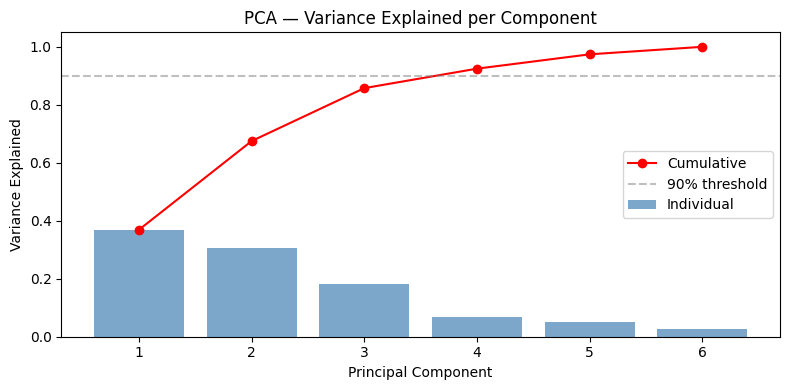

Variance explained per component:
  PC1: 0.369  (cumulative: 0.369)
  PC2: 0.306  (cumulative: 0.675)
  PC3: 0.183  (cumulative: 0.858)
  PC4: 0.067  (cumulative: 0.925)
  PC5: 0.049  (cumulative: 0.974)
  PC6: 0.026  (cumulative: 1.000)

2D PCA captures: 67.5% of total variance


In [14]:
scaler = StandardScaler()
X_scaled= scaler.fit_transform(df_drivers[FEATURE_COLS])

# Full PCS first - check how many components we actually need
pca_full= PCA(n_components=6)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax =plt.subplots(figsize=(8,4))
ax.bar(range(1,7),pca_full.explained_variance_ratio_,
       alpha=0.7, color='steelblue', label='Individual'
       )
ax.plot(range(1,7), cumvar, 'ro-',
        label='Cumulative')
ax.axhline(0.9,color='gray',linestyle='--',alpha=0.5, label='90% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained')
ax.set_title('PCA — Variance Explained per Component')
ax.set_xticks(range(1, 7))
ax.legend()
plt.tight_layout()
plt.show()

print("Variance explained per component:")
for i, v in enumerate(pca_full.explained_variance_ratio_):
    print(f"  PC{i+1}: {v:.3f}  (cumulative: {cumvar[i]:.3f})")

# 2D for visualization
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)
print(f"\n2D PCA captures: {pca_2d.explained_variance_ratio_.sum():.1%} of total variance")

## Step 5 — Choose K with the Elbow Method

K-Means requires the number of clusters upfront. We don't know K —
so we run K-Means for K=2 to 8 and plot **inertia** (sum of squared
distances from each point to its cluster center).

Inertia always drops as K increases. The "elbow" is where the curve
bends and gains flatten out — adding more clusters stops being meaningful.
That bend is our K.

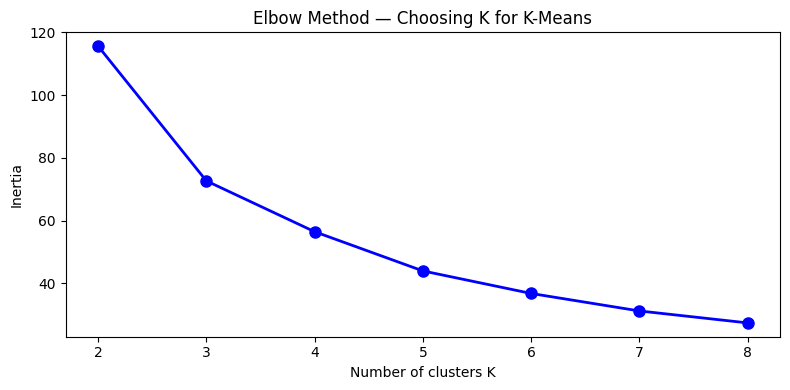

Inertia values:
  K=2: 115.62
  K=3: 72.68
  K=4: 56.48
  K=5: 43.98
  K=6: 36.80
  K=7: 31.22
  K=8: 27.42


In [15]:
inertias= []
K_range= range(2,9)

for k in K_range:
  km= KMeans(n_clusters=k, random_state=42,n_init=10)
  km.fit(X_scaled)
  inertias.append(km.inertia_)



plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of clusters K')
plt.ylabel('Inertia')
plt.title('Elbow Method — Choosing K for K-Means')
plt.xticks(K_range)
plt.tight_layout()
plt.show()

print("Inertia values:")
for k, v in zip(K_range, inertias):
    print(f"  K={k}: {v:.2f}")

## Step 6 — K-Means Clustering (K=4)

Elbow method pointed to K=4 — the sharpest bend in the inertia curve
and the number that maps most naturally to real F1 driving archetypes:
- Aggressive brakers
- Smooth/committed
- Mechanical grip style  
- Midfield/conservative

We cluster on the full 6D scaled features (not PCA) — PCA is only
for visualization. Clustering in the original feature space is more
accurate because we keep all 6 dimensions of information.

In [18]:
# Cluster on SCALED features - not PCA
## PCA is only for visualization, clustering in full 6D is more accurate

kmeans= KMeans(n_clusters=4, random_state=42,n_init=10)
df_drivers['Cluster']= kmeans.fit_predict(X_scaled)

#See who ended up in each cluster
print("==CLUSTER ASSIGNMENTS==\n")
for cluster_id in sorted(df_drivers['Cluster'].unique()):
  group= df_drivers[df_drivers['Cluster']== cluster_id]
  drivers= group['Driver'].tolist()
  teams= group['Team'].tolist()
  print(f"Cluster {cluster_id} ({len(group)} drivers):")
  for d, t in zip(drivers, teams):
        print(f"  #{d:>3}  {t}")


# Cluster centers — what does each cluster look like on average?
centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=FEATURE_COLS
)
centers.index.name = 'Cluster'
print("\n=== CLUSTER CENTERS (original scale) ===")
print(centers.round(4).to_string())

==CLUSTER ASSIGNMENTS==

Cluster 0 (14 drivers):
  #  1  Red Bull Racing
  # 10  Alpine
  # 11  Red Bull Racing
  # 14  Aston Martin
  # 18  Aston Martin
  # 20  Haas F1 Team
  # 22  Red Bull Racing
  # 24  Kick Sauber
  # 27  Kick Sauber
  #  3  RB
  # 30  Racing Bulls
  #  6  Racing Bulls
  # 77  Kick Sauber
  # 81  McLaren
Cluster 1 (6 drivers):
  # 12  Mercedes
  # 16  Ferrari
  # 23  Williams
  # 44  Ferrari
  # 63  Mercedes
  #  7  Alpine
Cluster 2 (6 drivers):
  #  2  Williams
  # 31  Haas F1 Team
  # 43  Alpine
  #  5  Kick Sauber
  # 55  Williams
  # 87  Haas F1 Team
Cluster 3 (1 drivers):
  #  4  McLaren

=== CLUSTER CENTERS (original scale) ===
         brake_application_pct  full_throttle_pct  coasting_pct  throttle_smoothness  min_speed_ratio  drs_usage_pct
Cluster                                                                                                             
0                       0.1233             0.7186        0.0120              15.0395           0.2283 

## Clustering V1 → Problem → V2

**V1 result:** Norris isolated into his own cluster (Cluster 3, 1 driver).
A cluster of 1 is always a red flag — not a real pattern.

**Root cause:** `drs_usage_pct = 0.000` for NOR across all 10 circuits.
FastF1 DRS channel corrupted for McLaren. K-Means saw him as an extreme
outlier on that feature and separated him completely.

**Fix:** Remove `drs_usage_pct` from features. DRS in the Race Simulator
(Module 4) is a race rule, not a learned feature — so this removal has
zero impact on downstream modules.

**Lesson:** Always inspect cluster assignments. If one cluster has
1 driver, something is wrong with the data, not the driver.

In [19]:
# Drop drs_usage_pct — FastF1 DRS channel is unreliable for some teams
# Norris isolated into his own cluster purely due to this data issue
# Lesson: one bad feature can dominate clustering — always inspect results

FEATURE_COLS_CLEAN = [
    'brake_application_pct',
    'full_throttle_pct',
    'coasting_pct',
    'throttle_smoothness',
    'min_speed_ratio',
]

scaler_clean = StandardScaler()
X_clean = scaler_clean.fit_transform(df_drivers[FEATURE_COLS_CLEAN])

kmeans_clean = KMeans(n_clusters=4, random_state=42, n_init=10)
df_drivers['Cluster'] = kmeans_clean.fit_predict(X_clean)

print("=== CLUSTER ASSIGNMENTS (DRS removed) ===\n")
for cluster_id in sorted(df_drivers['Cluster'].unique()):
    group = df_drivers[df_drivers['Cluster'] == cluster_id]
    print(f"Cluster {cluster_id} ({len(group)} drivers):")
    for _, row in group.iterrows():
        print(f"  #{row['Driver']:>3}  {row['Team']}")
    print()

centers_clean = pd.DataFrame(
    scaler_clean.inverse_transform(kmeans_clean.cluster_centers_),
    columns=FEATURE_COLS_CLEAN
)
print("=== CLUSTER CENTERS ===")
print(centers_clean.round(4).to_string())

=== CLUSTER ASSIGNMENTS (DRS removed) ===

Cluster 0 (2 drivers):
  #  4  McLaren
  # 81  McLaren

Cluster 1 (14 drivers):
  #  1  Red Bull Racing
  # 10  Alpine
  # 11  Red Bull Racing
  # 14  Aston Martin
  # 18  Aston Martin
  # 20  Haas F1 Team
  # 22  Red Bull Racing
  # 24  Kick Sauber
  # 27  Kick Sauber
  #  3  RB
  # 30  Racing Bulls
  #  5  Kick Sauber
  #  6  Racing Bulls
  # 77  Kick Sauber

Cluster 2 (5 drivers):
  #  2  Williams
  # 31  Haas F1 Team
  # 43  Alpine
  # 55  Williams
  # 87  Haas F1 Team

Cluster 3 (6 drivers):
  # 12  Mercedes
  # 16  Ferrari
  # 23  Williams
  # 44  Ferrari
  # 63  Mercedes
  #  7  Alpine

=== CLUSTER CENTERS ===
   brake_application_pct  full_throttle_pct  coasting_pct  throttle_smoothness  min_speed_ratio
0                 0.1100             0.6612        0.0158              14.6270           0.2341
1                 0.1246             0.7203        0.0114              15.0674           0.2273
2                 0.1426             0.6974 

In [20]:
# PCA on clean features first (4 components = 92.5% variance)
# then UMAP finds non-linear structure in that clean space

pca_4d= PCA(n_components=4, random_state=42)
X_pca4= pca_4d.fit_transform(X_clean)

reducer= umap.UMAP(n_components=2, random_state=42,n_neighbors=8,min_dist=0.3)
X_umap= reducer.fit_transform(X_pca4)

df_drivers['UMAP1'] = X_umap[:, 0]
df_drivers['UMAP2'] = X_umap[:, 1]

print(f"UMAP complete — shape: {X_umap.shape}")
print(df_drivers[['Driver', 'Team', 'Cluster', 'UMAP1', 'UMAP2']].to_string())

UMAP complete — shape: (27, 2)
   Driver             Team  Cluster     UMAP1      UMAP2
0       1  Red Bull Racing        1 -2.401057  15.629615
1      10           Alpine        1 -3.399446  13.922701
2      11  Red Bull Racing        1 -1.942266  15.436919
3      12         Mercedes        3 -1.051013  11.382689
4      14     Aston Martin        1 -0.940610  14.676647
5      16          Ferrari        3 -0.321583  11.313084
6      18     Aston Martin        1 -1.345932  15.648411
7       2         Williams        2  0.493615  14.585149
8      20     Haas F1 Team        1 -0.281634  16.053761
9      22  Red Bull Racing        1 -3.261662  14.517574
10     23         Williams        3  0.118790  10.910763
11     24      Kick Sauber        1  0.072500  15.271875
12     27      Kick Sauber        1 -0.665349  15.655662
13      3               RB        1 -2.712428  14.301485
14     30     Racing Bulls        1 -2.943785  15.355854
15     31     Haas F1 Team        2  0.232761  12.758423


## Step 7 — UMAP Visualization

UMAP (Uniform Manifold Approximation and Projection) finds the
best 2D layout of the data that keeps similar drivers close together.

Unlike PCA (linear), UMAP captures non-linear relationships —
drivers who are similar in complex combinations of features end up
near each other even if no single feature separates them cleanly.

We ran PCA to 4D first (92.5% variance), then UMAP on those 4
clean dimensions. This is more stable than UMAP on raw features.

In [21]:
# Team colors — official F1 2024/2025 palette
TEAM_COLORS = {
    'Red Bull Racing': '#3671C6',
    'Ferrari':         '#E8002D',
    'Mercedes':        '#27F4D2',
    'McLaren':         '#FF8000',
    'Aston Martin':    '#229971',
    'Alpine':          '#FF87BC',
    'Williams':        '#64C4FF',
    'RB':              '#6692FF',
    'Racing Bulls':    '#6692FF',
    'Haas F1 Team':    '#B6BABD',
    'Kick Sauber':     '#52E252',
}

CLUSTER_NAMES = {
    0: 'Cluster 0 — McLaren Mechanical Grip',
    1: 'Cluster 1 — Committed Throttle',
    2: 'Cluster 2 — Late Brakers',
    3: 'Cluster 3 — Smooth Precision',
}

# Driver number → code mapping for labels
DRIVER_CODES = {
    '1':'VER','4':'NOR','10':'GAS','11':'PER','12':'ANT',
    '14':'ALO','16':'LEC','18':'STR','2':'SAR','20':'MAG',
    '22':'TSU','23':'ALB','24':'ZHO','27':'HUL','3':'RIC',
    '30':'LAW','31':'OCO','43':'COL','44':'HAM','5':'BWT',
    '55':'SAI','6':'HAD','63':'RUS','7':'DOO','77':'BOT',
    '81':'PIA','87':'BEA'
}

fig = go.Figure()

# Plot each cluster as a separate trace so it appears in the legend
for cluster_id, cluster_name in CLUSTER_NAMES.items():
    mask = df_drivers['Cluster'] == cluster_id
    subset = df_drivers[mask]

    fig.add_trace(go.Scatter(
        x=subset['UMAP1'],
        y=subset['UMAP2'],
        mode='markers+text',
        name=cluster_name,
        text=[DRIVER_CODES.get(str(d), str(d)) for d in subset['Driver']],
        textposition='top center',
        marker=dict(
            size=14,
            color=[TEAM_COLORS.get(t, '#888888') for t in subset['Team']],
            line=dict(width=2, color='white'),
            symbol=['circle', 'diamond', 'square', 'cross'][cluster_id]
        ),
        textfont=dict(size=10, color='white')
    ))

fig.update_layout(
    title='F1 Driver Style Fingerprinting — UMAP Clusters (2024/2025)',
    xaxis_title='UMAP Dimension 1',
    yaxis_title='UMAP Dimension 2',
    plot_bgcolor='#1a1a2e',
    paper_bgcolor='#16213e',
    font=dict(color='white'),
    legend=dict(
        bgcolor='rgba(0,0,0,0.5)',
        bordercolor='gray',
        borderwidth=1
    ),
    width=900,
    height=600
)

fig.show()

## Reading the UMAP Plot

The axes have no literal meaning — UMAP Dimension 1 and 2 are not
interpretable numbers. What matters is **distance between points**:
drivers close together have similar styles, drivers far apart are different.

**Key findings:**
- HAM + LEC are neighbours despite different teams/eras → genuine style signal
- VER is in Committed Throttle, NOT Smooth Precision → aggressive on throttle
  despite being precise. The data distinguishes commitment from smoothness.
- NOR + PIA form their own cluster → likely car effect (McLaren's exceptional
  mechanical grip) as much as individual style
- Clusters do NOT map to teams → style is individual, not team-driven ✅

**Known limitation:** Cannot fully separate driver style from car
characteristics with telemetry alone.

In [22]:

import plotly.graph_objects as go

features_display = [
    'brake_application_pct',
    'full_throttle_pct',
    'coasting_pct',
    'throttle_smoothness',
    'min_speed_ratio'
]

labels = [
    'Brake Application',
    'Full Throttle',
    'Coasting',
    'Throttle Aggression',
    'Corner Speed'
]

# Normalize each feature 0-1 across all drivers so radar is readable
df_norm = df_drivers.copy()
for f in features_display:
    mn, mx = df_drivers[f].min(), df_drivers[f].max()
    df_norm[f] = (df_drivers[f] - mn) / (mx - mn)

CLUSTER_COLORS = {
    0: '#FF8000',   # McLaren orange
    1: '#3671C6',   # RB blue
    2: '#B6BABD',   # Haas grey
    3: '#E8002D',   # Ferrari red
}

fig = go.Figure()

for cluster_id, cluster_name in CLUSTER_NAMES.items():
    subset = df_norm[df_norm['Cluster'] == cluster_id]
    means = subset[features_display].mean().tolist()
    means += [means[0]]  # close the polygon

    fig.add_trace(go.Scatterpolar(
        r=means,
        theta=labels + [labels[0]],
        name=cluster_name,
        line=dict(color=CLUSTER_COLORS[cluster_id], width=2),
        fill='toself',
        fillcolor=CLUSTER_COLORS[cluster_id],
        opacity=0.2
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(visible=True, range=[0, 1]),
        bgcolor='#1a1a2e'
    ),
    title='Driver Style Clusters — Feature Profiles',
    paper_bgcolor='#16213e',
    font=dict(color='white'),
    width=700,
    height=600
)

fig.show()

## How to read this radar chart

Each spoke = one feature. Further out = higher value relative to all drivers.
Color = cluster. Shapes overlap because no cluster is extreme on every feature —
driving style is a combination, not a single dimension.

The McLaren cluster (orange) is the most distinctive — extreme coasting,
low brake. This is likely the 2024/2025 McLaren car as much as the drivers.

The Smooth Precision cluster (red) is distinguished not by being high
on any one feature, but by being consistently low on coasting and
throttle smoothness — precision through absence of excess inputs.